<a href="https://colab.research.google.com/github/harrytotton/nj-minimum-wage-employment-or-minimum-wage-causal-inference/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimum Wage and Employment: A Causal Inference Analysis

**Question:** Does raising the minimum wage cause a reduction in employment in low-wage sectors?

This project uses New Jersey's 2019 minimum wage increase as a natural experiment, comparing it against Pennsylvania (which kept the federal minimum wage unchanged) to isolate the policy's causal effect on employment — mirroring the design of Card & Krueger's influential 1994 study.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

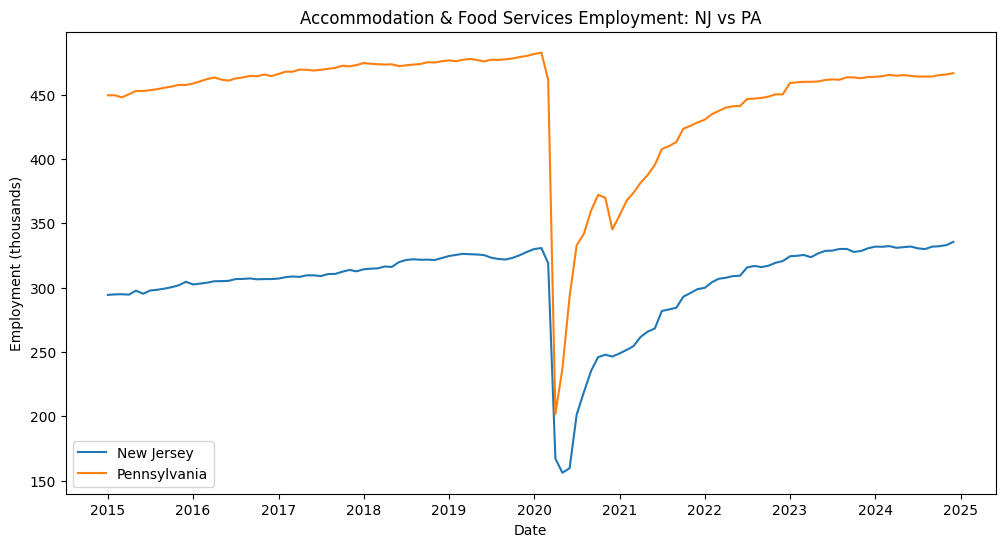

In [9]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df.index, df['NJ_employment'], label='New Jersey')
ax.plot(df.index, df['PA_employment'], label='Pennsylvania')
ax.set_title('Accommodation & Food Services Employment: NJ vs PA')
ax.set_xlabel('Date')
ax.set_ylabel('Employment (thousands)')
ax.legend()
plt.show()


## Method 1: Difference-in-Differences

Testing whether New Jersey's employment diverged from Pennsylvania's after the July 2019 minimum wage increase. The `post_x_treated` coefficient below is the causal estimate — the extra change NJ experienced beyond what Pennsylvania experienced over the same period.


In [10]:
long_df['treated'] = (long_df['state'] == 'NJ_employment').astype(int)
long_df['post_x_treated'] = long_df['post'] * long_df['treated']

X = long_df[['treated', 'post', 'post_x_treated']]
X = sm.add_constant(X)
y = long_df['employment']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             employment   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     3414.
Date:                Mon, 31 Aug 2026   Prob (F-statistic):          5.85e-116
Time:                        12:28:52   Log-Likelihood:                -440.58
No. Observations:                 124   AIC:                             889.2
Df Residuals:                     120   BIC:                             900.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            466.1981      1.169    398.

In [11]:
model_robust = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
print(model_robust.summary())


                            OLS Regression Results                            
Dep. Variable:             employment   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     2899.
Date:                Mon, 31 Aug 2026   Prob (F-statistic):          9.48e-112
Time:                        12:29:30   Log-Likelihood:                -440.58
No. Observations:                 124   AIC:                             889.2
Df Residuals:                     120   BIC:                             900.4
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            466.1981      2.245    207.

## Method 2: Synthetic Control

A single-state comparison (NJ vs PA) relies on Pennsylvania alone being a good match. As a robustness check, a "synthetic NJ" is constructed here as a weighted blend of several states that kept the federal minimum wage unchanged, chosen to best replicate NJ's employment trend *before* the wage law took effect.


In [12]:
donor_states = {
    'TX': 'SMS48000007072000001',
    'GA': 'SMS13000007072000001',
    'WI': 'SMS55000007072000001',
    'IN': 'SMS18000007072000001',
    'KS': 'SMS20000007072000001',
}

donors = pd.DataFrame()
for state, code in donor_states.items():
    donors[state] = web.DataReader(code, 'fred', start, end)[code]

donors = donors.loc['2015-01-01':'2020-02-01']
donors.head()


,TX,GA,WI,IN,KS
DATE,,,,,
2015-01-01,1085.3,394.2,230.1,257.2,109.2
2015-02-01,1091.6,396.5,230.2,257.8,109.6
2015-03-01,1092.9,397.0,231.2,258.0,109.1
2015-04-01,1100.2,397.5,231.6,258.2,109.0
2015-05-01,1105.9,399.3,232.2,259.3,108.6


In [14]:
from scipy.optimize import minimize

# Pre-treatment period only — this is what we fit the weights on
pre_period = df_clean.loc['2015-01-01':'2019-06-01']
nj_pre = pre_period['NJ_employment'].values
donors_pre = donors.loc['2015-01-01':'2019-06-01'].values

n_donors = donors.shape[1]
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0, 1) for _ in range(n_donors)]
init_weights = np.repeat(1/n_donors, n_donors)

# Scale down for a well-behaved optimization
nj_pre_scaled = nj_pre / 100
donors_pre_scaled = donors_pre / 100

def loss(weights):
    synthetic = donors_pre_scaled @ weights
    return np.sum((nj_pre_scaled - synthetic) ** 2)

result = minimize(
    loss, init_weights, bounds=bounds, constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-12}
)
weights = result.x

print(result.success)
print(result.message)
print(result.fun)
for state, w in zip(donors.columns, weights):
    print(f"{state}: {w:.3f}")


True
Optimization terminated successfully
0.014948686121910007
TX: 0.187
GA: 0.000
WI: 0.000
IN: 0.000
KS: 0.813


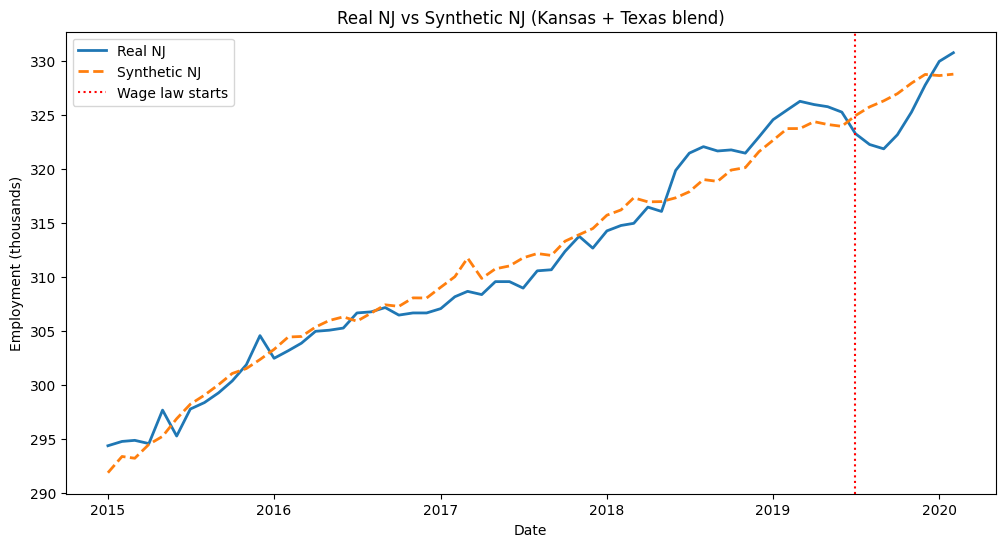

In [15]:
# Apply weights to the FULL donor period (not just pre-treatment)
donors_full = donors.values
synthetic_nj = donors_full @ weights

# Build comparison dataframe
compare_df = pd.DataFrame({
    'Real NJ': df_clean['NJ_employment'].values,
    'Synthetic NJ': synthetic_nj
}, index=df_clean.index)

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(compare_df.index, compare_df['Real NJ'], label='Real NJ', linewidth=2)
ax.plot(compare_df.index, compare_df['Synthetic NJ'], label='Synthetic NJ', linestyle='--', linewidth=2)
ax.axvline(pd.Timestamp('2019-07-01'), color='red', linestyle=':', label='Wage law starts')
ax.set_title('Real NJ vs Synthetic NJ (Kansas + Texas blend)')
ax.set_xlabel('Date')
ax.set_ylabel('Employment (thousands)')
ax.legend()
plt.show()


In [16]:
compare_df['gap'] = compare_df['Real NJ'] - compare_df['Synthetic NJ']
post_gap = compare_df.loc['2019-07-01':, 'gap']

print(post_gap.mean())
print(post_gap)


-1.7220998516971946
DATE
2019-07-01   -1.681650
2019-08-01   -3.481131
2019-09-01   -4.442657
2019-10-01   -3.804703
2019-11-01   -2.678535
2019-12-01   -0.990321
2020-01-01    1.316610
2020-02-01    1.985588
Name: gap, dtype: float64


## Conclusion

Two independent methods were used to test whether New Jersey's 2019 minimum wage increase reduced employment, relative to a credible counterfactual:

| Method | Estimate | Result |
|---|---|---|
| Difference-in-Differences | +2.56k jobs (HAC-adjusted SE) | p = 0.51 — not statistically significant |
| Synthetic Control | −1.72k jobs (average post-period gap) | Sign flips over the post-period; not a consistent effect |

Both methods agree: there is no robust evidence that the minimum wage increase reduced employment in the accommodation and food services sector in the eight months following the policy change.

**Limitations:** the post-treatment window is short (8 months) before COVID-19 disrupted the data, limiting statistical power to detect a small effect. The synthetic control is built from only two donor states (Kansas, Texas), and effects on hours or wages (as opposed to headcount) are not tested here.
